Used GPT to diagnose some issues with setting up gpu, cpu usgae  (cell output above)

this cell just calcs for sigma =5 and simga =10 the limit results.

##  Good!


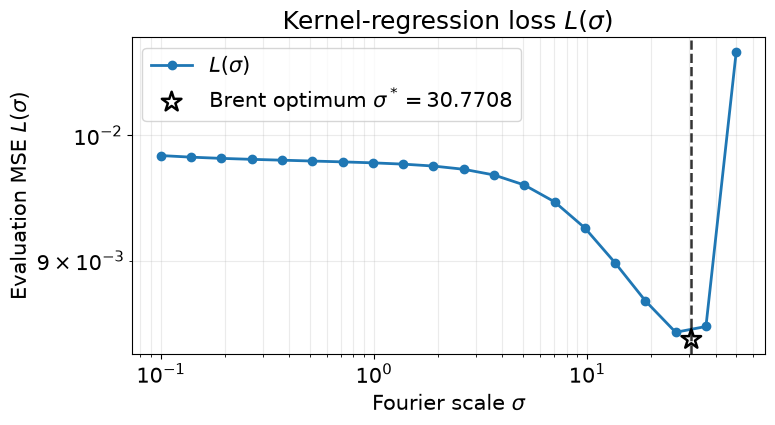

In [21]:
# ============================================================================
# PLOT L(sigma) OVER THE SIGMA GRID
# ============================================================================

sigma_grid_plot = np.asarray(
    sigma_search[
        "sigma_grid"
    ],
    dtype=np.float64,
)


loss_grid_plot = []


for sigma in sigma_grid_plot:

    loss, _ = kernel_loss_and_sigma_derivative(
        float(sigma),
        X_train,
        y_train,
        X_eval,
        y_eval,
        ridge=ridge,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    loss_grid_plot.append(
        float(loss)
    )


loss_grid_plot = np.asarray(
    loss_grid_plot,
    dtype=np.float64,
)


plt.figure(
    figsize=(8, 4.5)
)


plt.plot(
    sigma_grid_plot,
    loss_grid_plot,
    "o-",
    linewidth=2.0,
    label=r"$L(\sigma)$",
)


# Brent optimum.
plt.scatter(
    [
        optimal_sigma
    ],
    [
        float(
            best_result[
                "loss"
            ]
        )
    ],
    marker="*",
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    zorder=4,
    label=(
        rf"Brent optimum "
        rf"$\sigma^*={optimal_sigma:.4f}$"
    ),
)


plt.axvline(
    optimal_sigma,
    color="black",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
)


if log_grid:
    plt.xscale(
        "log"
    )


plt.yscale(
    "log"
)


plt.xlabel(
    r"Fourier scale $\sigma$"
)


plt.ylabel(
    r"Evaluation MSE $L(\sigma)$"
)


plt.title(
    r"Kernel-regression loss $L(\sigma)$"
)


plt.grid(
    True,
    which="both",
    alpha=0.25,
)


plt.legend()


plt.tight_layout()

plt.show()

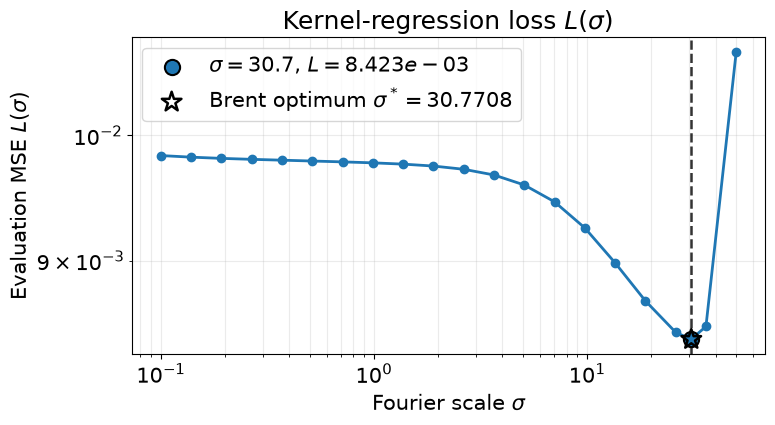

In [22]:
# Only calculate the extra sigma=30.8 point.
sigma_extra = 30.8

loss_extra = float(
    kernel_loss_and_sigma_derivative(
        sigma_extra,
        X_train,
        y_train,
        X_eval,
        y_eval,
        ridge=ridge,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )[0]
)


# Add it to the already-loaded plot data.
sigma_plot = np.append(
    sigma_grid_plot,
    sigma_extra,
)

loss_plot = np.append(
    loss_grid_plot,
    loss_extra,
)

order = np.argsort(
    sigma_plot
)

sigma_plot = sigma_plot[order]
loss_plot = loss_plot[order]


plt.figure(
    figsize=(8, 4.5)
)

plt.plot(
    sigma_plot,
    loss_plot,
    "o-",
    linewidth=2.0,
)

plt.scatter(
    [sigma_extra],
    [loss_extra],
    s=120,
    edgecolors="black",
    linewidths=1.5,
    zorder=5,
    label=(
        rf"$\sigma=30.8$, "
        rf"$L={loss_extra:.3e}$"
    ),
)

plt.scatter(
    [optimal_sigma],
    [float(best_result["loss"])],
    marker="*",
    s=220,
    facecolors="none",
    edgecolors="black",
    linewidths=1.8,
    zorder=6,
    label=(
        rf"Brent optimum "
        rf"$\sigma^*={optimal_sigma:.4f}$"
    ),
)

plt.axvline(
    optimal_sigma,
    color="black",
    linestyle="--",
    linewidth=1.8,
    alpha=0.8,
)

if log_grid:
    plt.xscale("log")

plt.yscale("log")

plt.xlabel(
    r"Fourier scale $\sigma$"
)

plt.ylabel(
    r"Evaluation MSE $L(\sigma)$"
)

plt.title(
    r"Kernel-regression loss $L(\sigma)$"
)

plt.grid(
    True,
    which="both",
    alpha=0.25,
)

plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
## Final Section to confirm behaviour of K_{NTK, \infty,\infty}

Vanilla eigenvalues surviving tolerance: 250
sigma=0.1: eigenvalues surviving tolerance=250
sigma=1: eigenvalues surviving tolerance=250
sigma=5: eigenvalues surviving tolerance=250
sigma=10: eigenvalues surviving tolerance=250
sigma=20: eigenvalues surviving tolerance=250
sigma=50: eigenvalues surviving tolerance=250
sigma=100: eigenvalues surviving tolerance=250
sigma=500: eigenvalues surviving tolerance=250


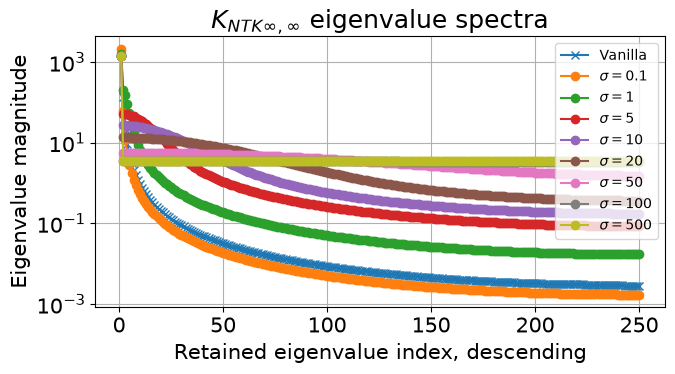

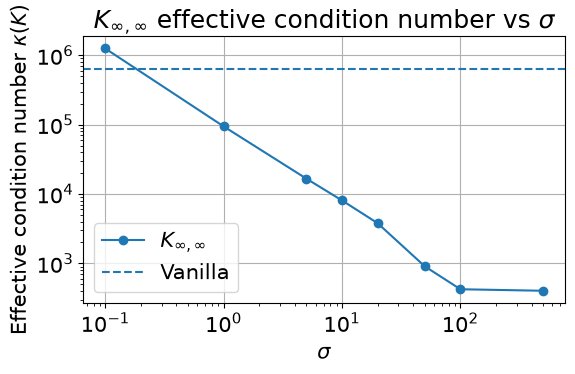

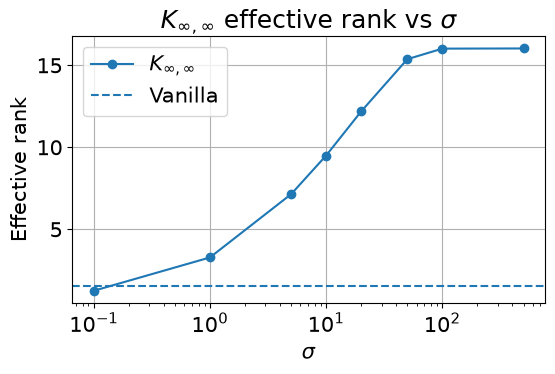


Vanilla condition number: 640267.1041274644
Vanilla effective rank: 1.5461472174770523
Vanilla retained eigenvalues: 250
sigma=0.1: condition number=1.256e+06, effective rank=1.250, retained eigenvalues=250
sigma=1: condition number=9.454e+04, effective rank=3.282, retained eigenvalues=250
sigma=5: condition number=1.667e+04, effective rank=7.142, retained eigenvalues=250
sigma=10: condition number=8.088e+03, effective rank=9.497, retained eigenvalues=250
sigma=20: condition number=3.796e+03, effective rank=12.182, retained eigenvalues=250
sigma=50: condition number=9.078e+02, effective rank=15.373, retained eigenvalues=250
sigma=100: condition number=4.232e+02, effective rank=16.016, retained eigenvalues=250
sigma=500: condition number=4.024e+02, effective rank=16.027, retained eigenvalues=250


In [69]:
#need update

depth = 2

sigma_w_sq = 2.0
sigma_b_sq = 1.0

sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

eig_tol_factor = 1e-9

#n_total was changed to 1000 so that the sigma to condition number plots match the same conditions as a later cell
#this is now 500, as standard in diss should be this
X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=500,
    train_every=2,
)

spectra = {}
condition_numbers = []
effective_ranks = []


# ------------------------------------------------------------
# Vanilla/no-map infinite-width NTK
# ------------------------------------------------------------

K_init_n, _ = analytic_ntk_matrix_2(
    X_train,
    depth=depth,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
)

cond_n, eigvals_n_raw = condition_number_psd(
    K_init_n,
    rtol=1e-9,
)

eigvals_n = threshold_eigvals(
    eigvals_n_raw,
    tol_factor=eig_tol_factor,
)

rank_n = effective_rank_from_eigvals(
    eigvals_n
)

print(
    "Vanilla eigenvalues surviving tolerance:",
    len(eigvals_n),
)


# ------------------------------------------------------------
# Infinite-Fourier / infinite-width NTK for each sigma
# K_{infinity,infinity}
# ------------------------------------------------------------

for sigma in sigma_values:

    K_init_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    cond_ff, eigvals_ff_raw = condition_number_psd(
        K_init_ff,
        rtol=1e-9,
    )

    eigvals_ff = threshold_eigvals(
        eigvals_ff_raw,
        tol_factor=eig_tol_factor,
    )

    spectra[sigma] = eigvals_ff

    condition_numbers.append(
        float(cond_ff)
    )

    effective_ranks.append(
        float(
            effective_rank_from_eigvals(
                eigvals_ff
            )
        )
    )

    print(
        f"sigma={sigma}: "
        f"eigenvalues surviving tolerance={len(eigvals_ff)}"
    )


# ------------------------------------------------------------
# Plot 1: eigenvalue spectra
# ------------------------------------------------------------

plt.figure(
    figsize=(7, 4)
)

plt.semilogy(
    range(
        1,
        len(eigvals_n) + 1,
    ),
    eigvals_n,
    marker="x",
    label="Vanilla",
)

for sigma in sigma_values:

    eigvals = spectra[
        sigma
    ]

    plt.semilogy(
        range(
            1,
            len(eigvals) + 1,
        ),
        eigvals,
        marker="o",
        label=rf"$\sigma={sigma}$",
    )

plt.xlabel(
    "Retained eigenvalue index, descending"
)

plt.ylabel(
    "Eigenvalue magnitude"
)

plt.title(
    r"$K_{NTK \infty,\infty}$ eigenvalue spectra"
)

plt.legend(
    fontsize=10
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Plot 2: condition number versus sigma
# ------------------------------------------------------------

plt.figure(
    figsize=(6, 4)
)

plt.plot(
    sigma_values,
    condition_numbers,
    marker="o",
    label=r"$K_{\infty,\infty}$",
)

plt.axhline(
    float(cond_n),
    linestyle="--",
    label="Vanilla",
)

plt.xscale(
    "log"
)

plt.yscale(
    "log"
)

plt.xlabel(
    r"$\sigma$"
)

plt.ylabel(
    r"Effective condition number $\kappa(K)$"
)

plt.title(
    r"$K_{\infty,\infty}$ effective condition number vs $\sigma$"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Plot 3: effective rank versus sigma
# ------------------------------------------------------------

plt.figure(
    figsize=(6, 4)
)

plt.plot(
    sigma_values,
    effective_ranks,
    marker="o",
    label=r"$K_{\infty,\infty}$",
)

plt.axhline(
    float(rank_n),
    linestyle="--",
    label="Vanilla",
)

plt.xscale(
    "log"
)

plt.xlabel(
    r"$\sigma$"
)

plt.ylabel(
    "Effective rank"
)

plt.title(
    r"$K_{\infty,\infty}$ effective rank vs $\sigma$"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Numerical results
# ------------------------------------------------------------

print()

print(
    "Vanilla condition number:",
    float(cond_n),
)

print(
    "Vanilla effective rank:",
    float(rank_n),
)

print(
    "Vanilla retained eigenvalues:",
    len(eigvals_n),
)

for sigma, cond, rank in zip(
    sigma_values,
    condition_numbers,
    effective_ranks,
):

    print(
        f"sigma={sigma}: "
        f"condition number={cond:.3e}, "
        f"effective rank={rank:.3f}, "
        f"retained eigenvalues={len(spectra[sigma])}"
    )

Number of failures: 0
Keeping 200 of 200 eigenmodes
Eigenvalue threshold: 1.151e-06


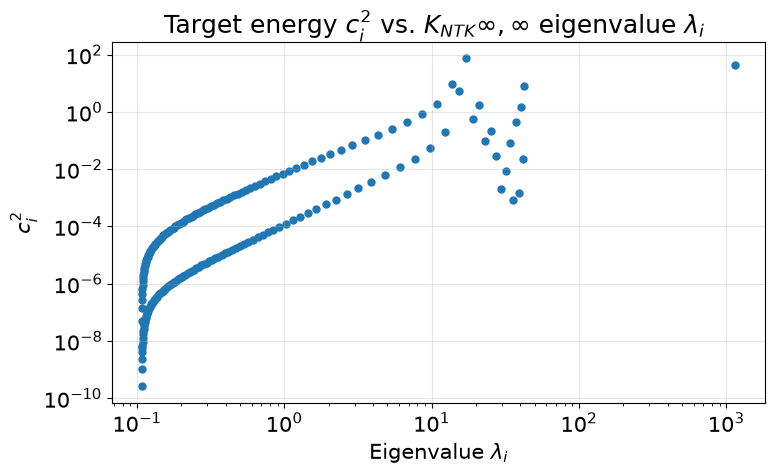

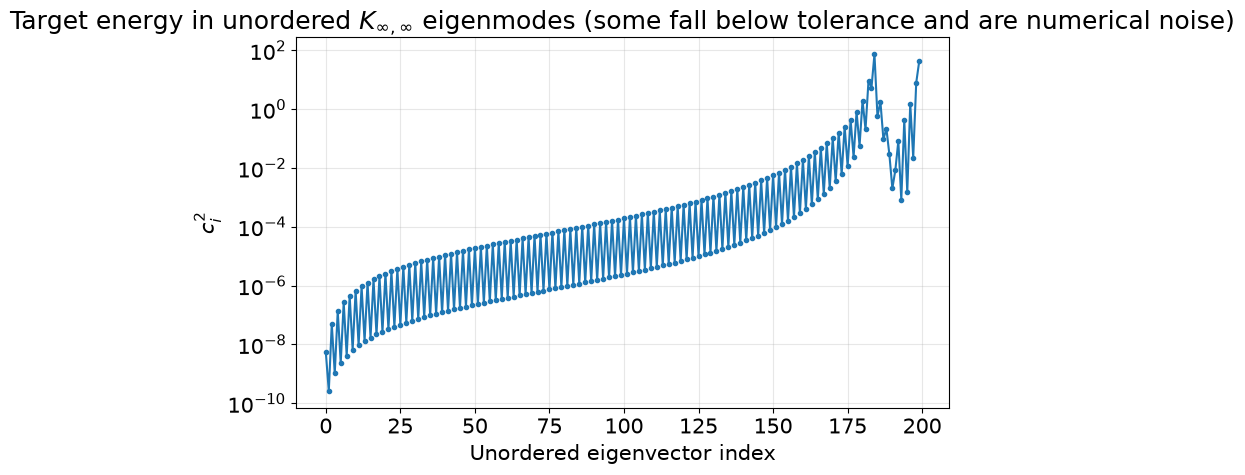

In [72]:
#init 

depth = 2

sigma_w_sq = 2.0
sigma_b_sq = 1.0

#sigma=5 so 200 should cover everything
n_total = 200

# Analytic infinite-Fourier scale
sigma = 5


# =========================================================
# Make points to train + test
# =========================================================

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=n_total,
    train_every=2,
)


# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)

#used in the next cell


# =========================================================
# Analytic infinite-Fourier / infinite-width NTK
#
# K_{infinity,infinity}
#
# No finite B is sampled here.
# No num_basis or finite Fourier feature map is used.
# =========================================================

K_init_ff, _ = expected_ntk_and_sigma_derivative(
    sigma,
    X_all,
    depth=depth,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
)


# =========================================================
# Eigendecomposition
# =========================================================

#ordered
eigenvals, eigenvectors = ntk_eigendecomposition(
    K_init_ff
)


#test
test_orthonormal(
    eigenvectors
)


#unordered
eigenvals_u, eigenvectors_u = np.linalg.eigh(
    np.asarray(K_init_ff)
)


c_ordered = []
c_unordered = []


# Eigenvectors are stored as columns.
for i in range(
    eigenvectors.shape[1]
):

    c_ordered.append(
        eigenvectors[:, i]
        @ y_all
    )

    c_unordered.append(
        eigenvectors_u[:, i]
        @ np.asarray(y_all)
    )


c_ordered = np.asarray(
    c_ordered
)

c_unordered = np.asarray(
    c_unordered
)

eigenvals = np.asarray(
    eigenvals
)


# =========================================================
# Remove numerical eigenvalue noise
# =========================================================

threshold = (
    1e-9
    * np.max(
        eigenvals
    )
)

keep = (
    eigenvals
    >= threshold
)


eigenvals_plot = eigenvals[
    keep
]

c_ordered_plot = c_ordered[
    keep
]


print(
    f"Keeping {keep.sum()} "
    f"of {len(eigenvals)} eigenmodes"
)

print(
    f"Eigenvalue threshold: "
    f"{threshold:.3e}"
)


# =========================================================
# Target energy versus K_{infinity,infinity} eigenvalue
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.scatter(
    eigenvals_plot,
    c_ordered_plot**2,
    s=25,
)

plt.xlabel(
    r"Eigenvalue $\lambda_i$"
)

plt.ylabel(
    r"$c_i^2$"
)

plt.title(
    r"Target energy $c_i^2$ vs. "
    r"$K_{NTK}\infty,\infty$ eigenvalue $\lambda_i$ "
)

plt.xscale(
    "log"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# =========================================================
# Target energy against unordered eigenvector index
# =========================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    range(
        len(c_unordered)
    ),
    c_unordered**2,
    marker="o",
    markersize=3,
)

plt.xlabel(
    "Unordered eigenvector index"
)

plt.ylabel(
    r"$c_i^2$"
)

plt.title(
    r"Target energy in unordered "
    r"$K_{\infty,\infty}$ eigenmodes "
    r"(some fall below tolerance and are numerical noise)"
)

plt.yscale(
    "log"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

0

sigma = 0.1
smallest eigenvalue = 4.300976456440e-04
largest eigenvalue  = 8.643746090353e+03
within tol


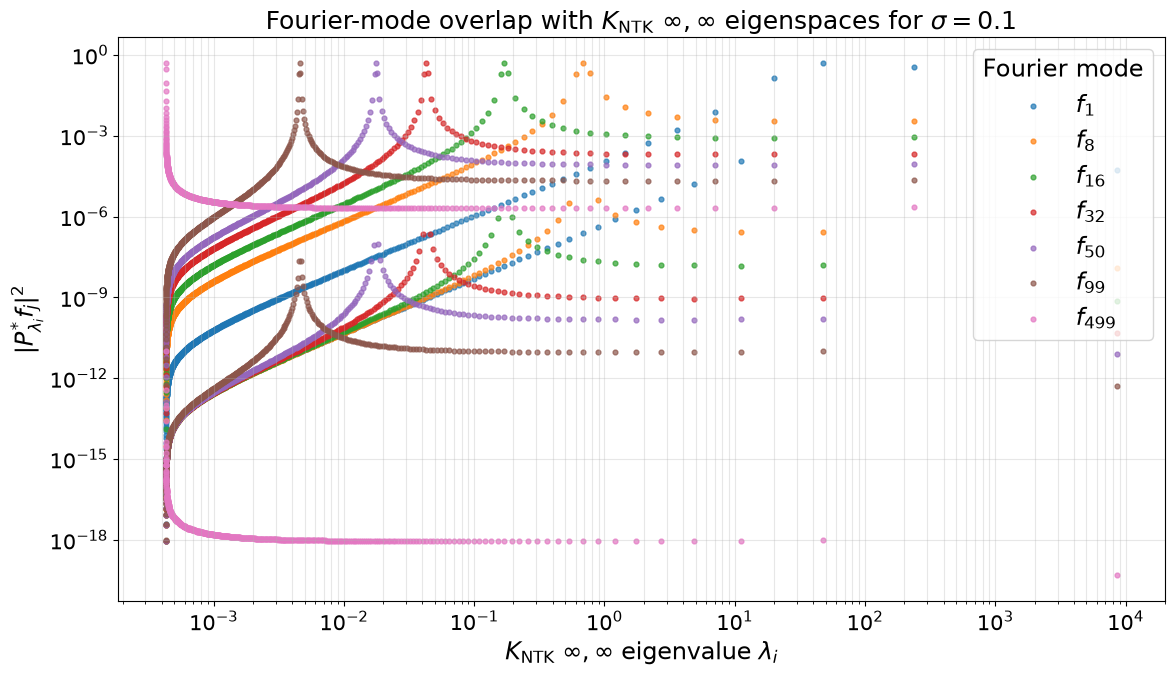

1

sigma = 1
smallest eigenvalue = 4.301016016385e-03
largest eigenvalue  = 6.507191422118e+03
within tol


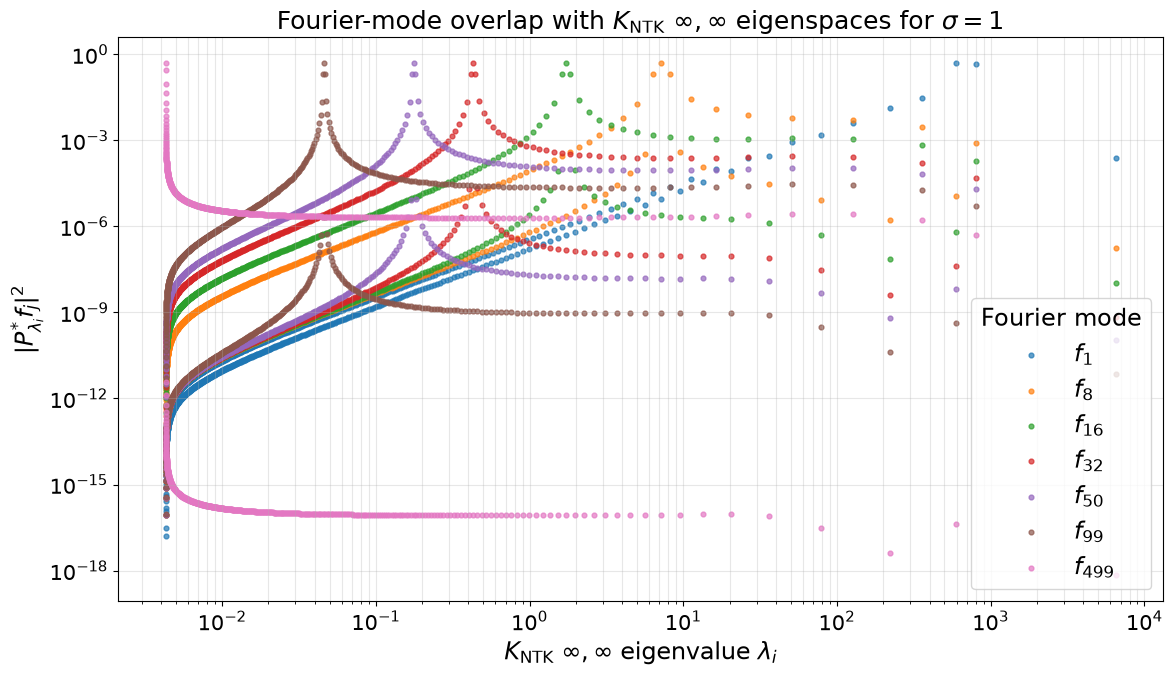

2

sigma = 5
smallest eigenvalue = 2.150994231038e-02
largest eigenvalue  = 5.756941417407e+03
within tol


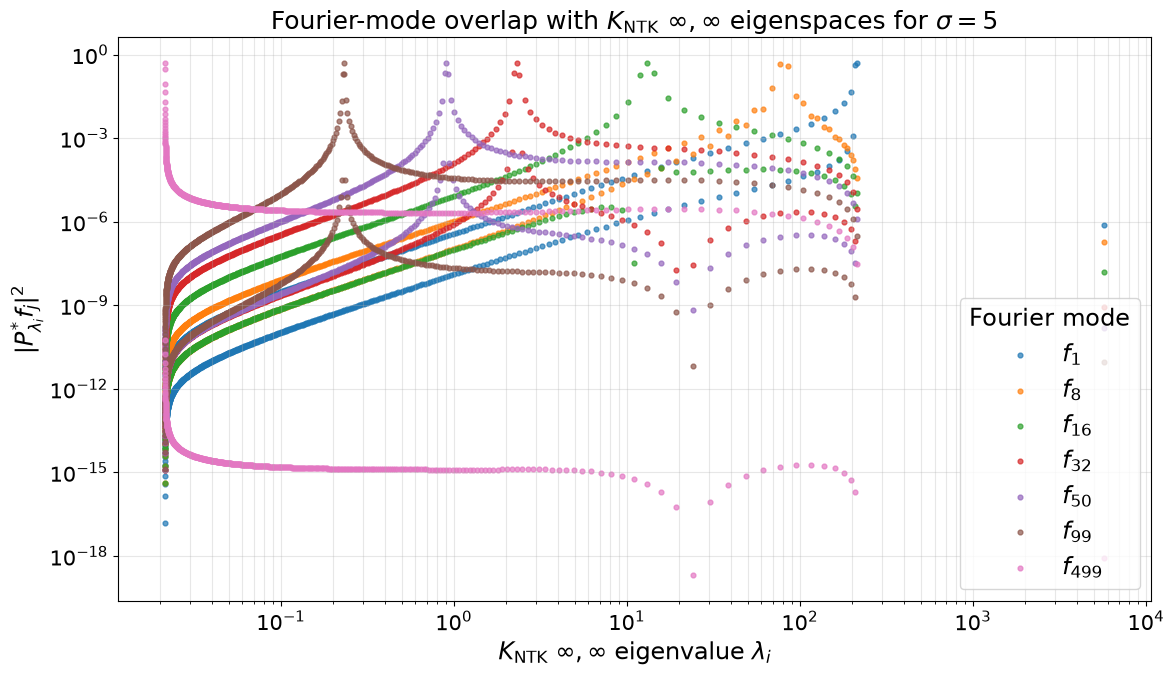

3

sigma = 10
smallest eigenvalue = 4.305034299280e-02
largest eigenvalue  = 5.652587477845e+03
within tol


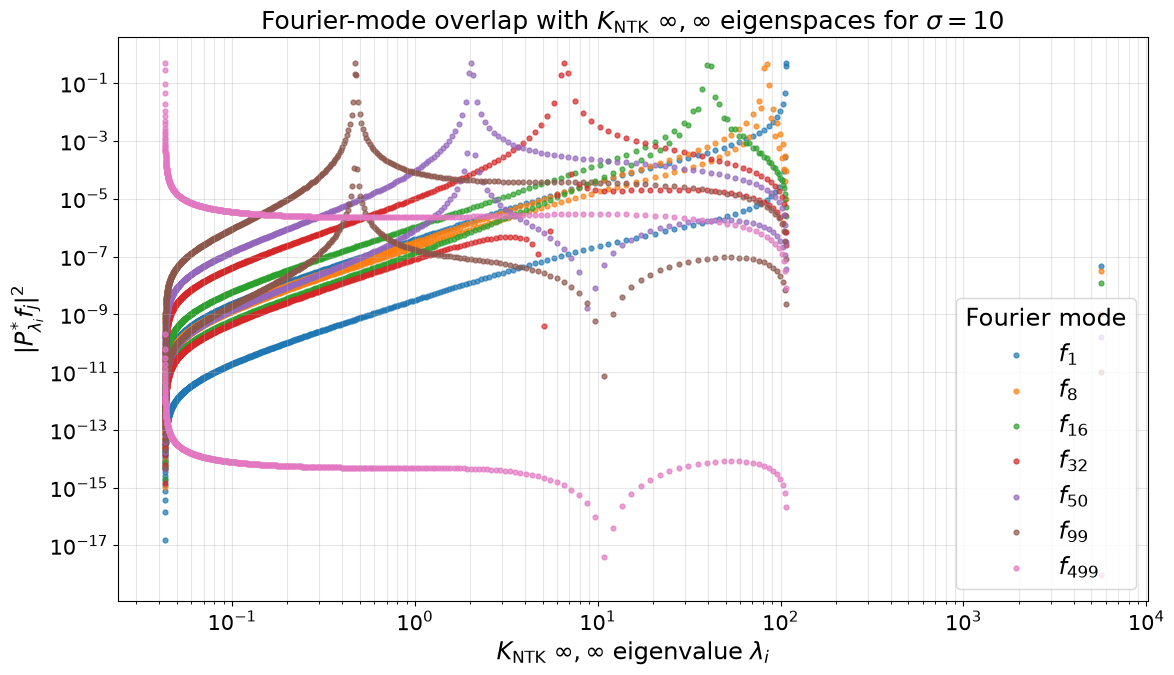

4

sigma = 15
smallest eigenvalue = 6.465201373955e-02
largest eigenvalue  = 5.617274420019e+03
within tol


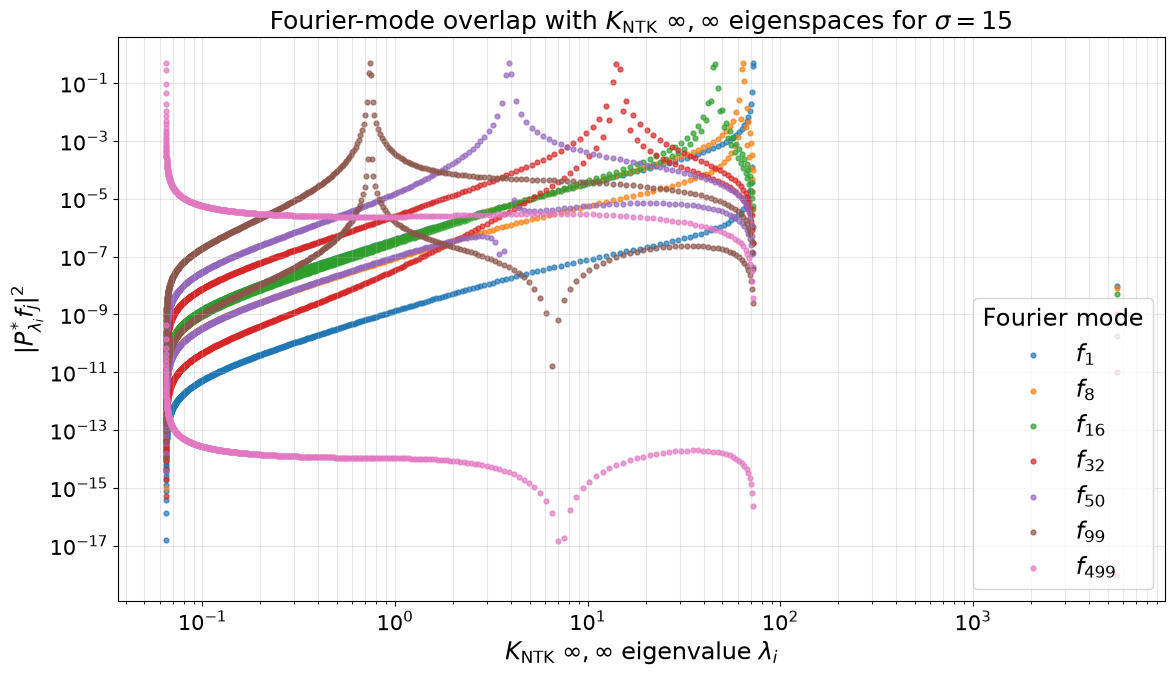

5

sigma = 20
smallest eigenvalue = 8.634648556856e-02
largest eigenvalue  = 5.599520840974e+03
within tol


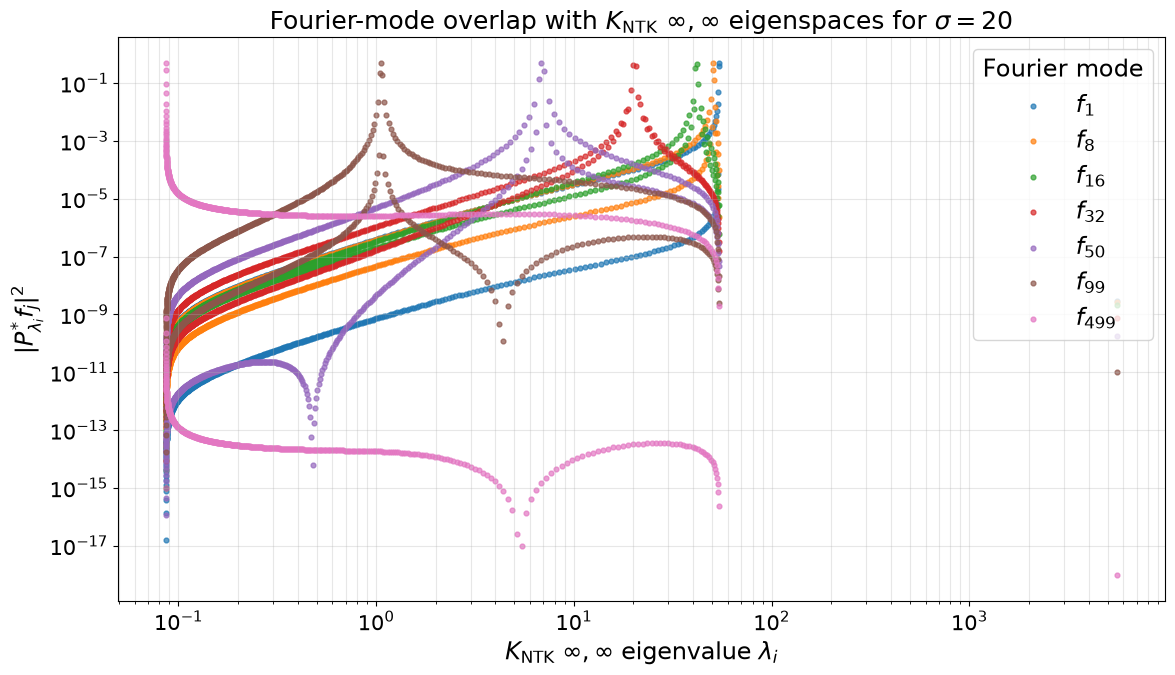

6

sigma = 25
smallest eigenvalue = 1.081664012036e-01
largest eigenvalue  = 5.588839274327e+03
within tol


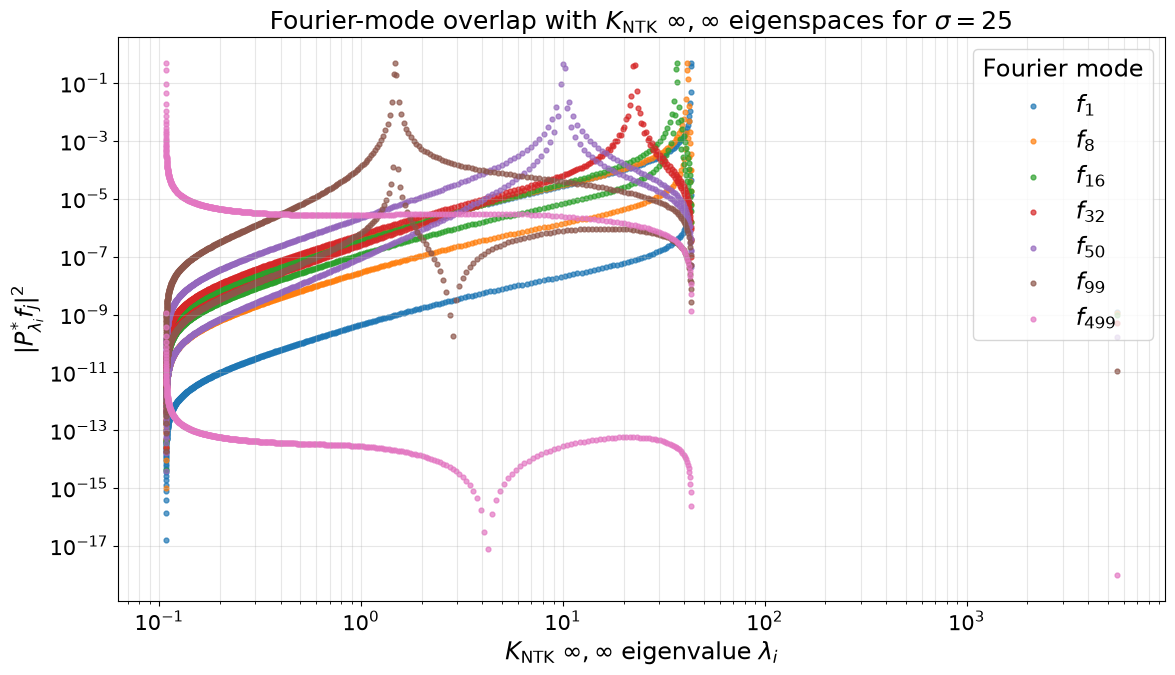

7

sigma = 30
smallest eigenvalue = 1.301459497006e-01
largest eigenvalue  = 5.581707155794e+03
within tol


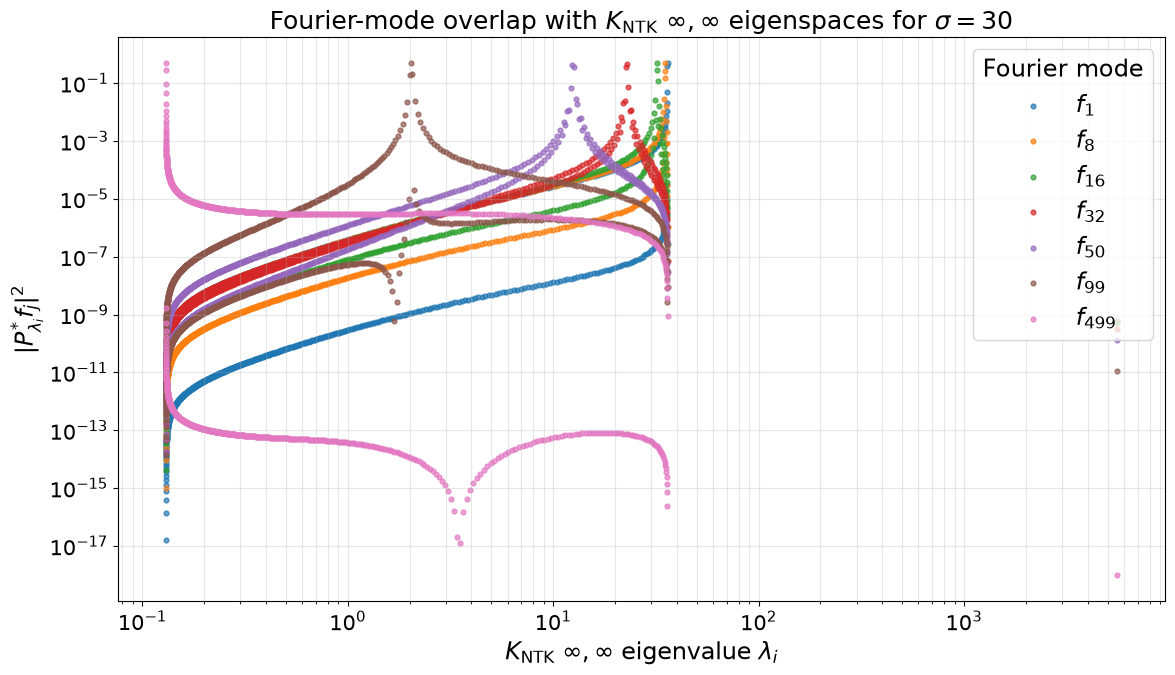

8

sigma = 100
smallest eigenvalue = 4.850038187061e-01
largest eigenvalue  = 5.556737590643e+03
within tol


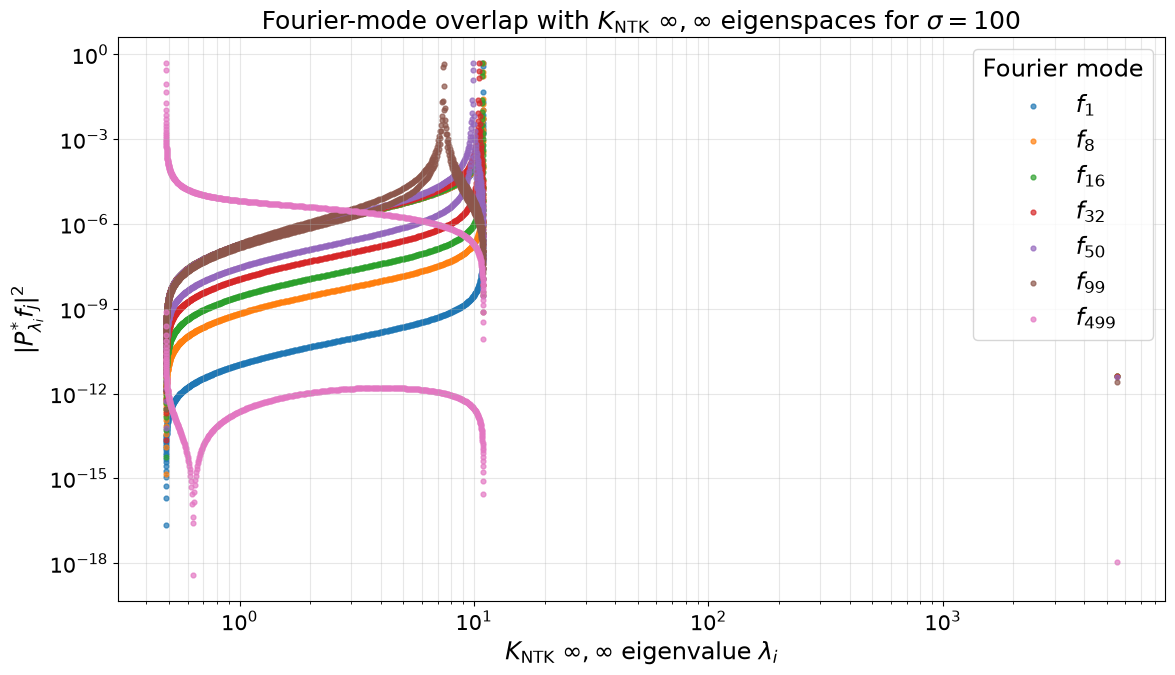

9

sigma = 200
smallest eigenvalue = 1.533496662031e+00
largest eigenvalue  = 5.551517028989e+03
within tol


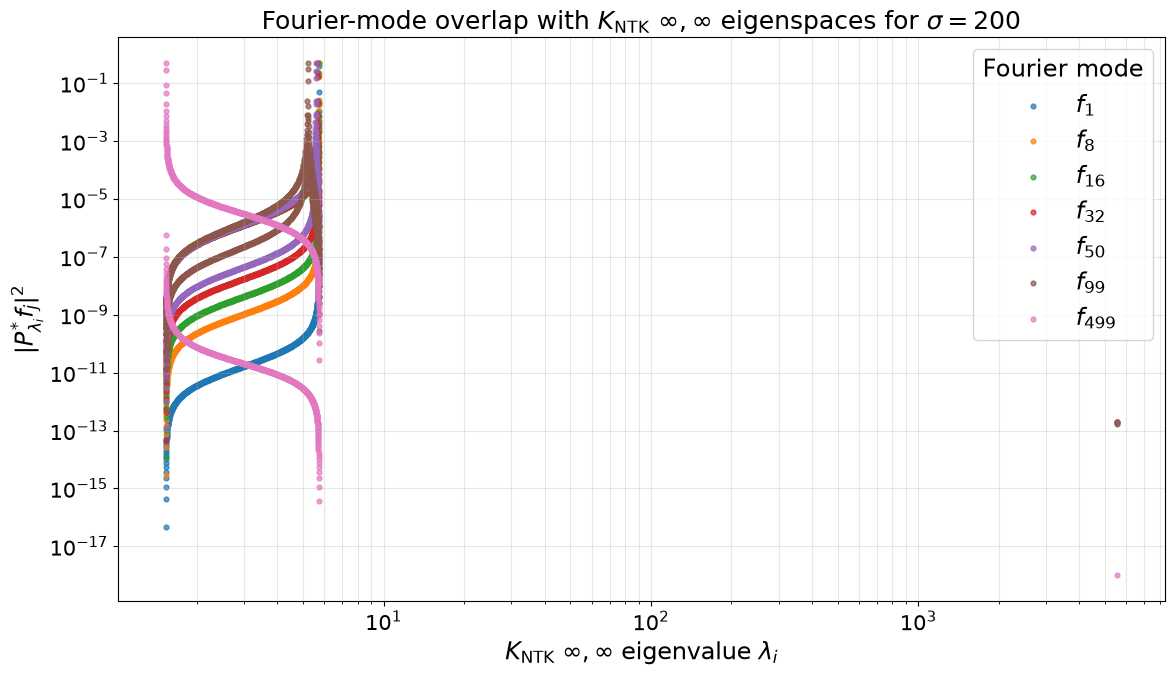

In [77]:
import numpy as np
import matplotlib.pyplot as plt


#small plot change which is reverted at end

plt.rcParams.update({
    # General text
    "font.size": 15,

    # Axis titles
    "axes.titlesize": 18,

    # x/y axis labels
    "axes.labelsize": 17,

    # Tick labels
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    # Legend
    "legend.fontsize": 17,
    "legend.title_fontsize": 17,

    # Figure-level titles, if used
    "figure.titlesize": 18,
})


# =========================================================
# Plot w_ij = |q_i^* f_j|^2 against NTK eigenvalue lambda_i
#
# Now uses the analytic infinite-Fourier / infinite-width
# kernel K_{NTK,infinity,infinity}.
#
# The function normalizes f_j internally, so w_ij is
# independent of epsilon0, eta, and training step.
# =========================================================

#change this guy!
#the largest my laptop allows is 1000, so i cannot cover sigma at 500 or else I'll get overlap / nt needs to be a bit over two thousand min
nt = 1000
#change this guy!


X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=nt,
    train_every=2,
)


f_max = nt // 2 - 1

j_values = [
    1,
    8,
    16,
    32,
    50,
    99,
    f_max,
]


# Full-grid coordinates and target values
x_full = X_all.reshape(-1)
y_true_plot = y_all.reshape(-1)

#used in the next cell


sigma_vals = [
    0.1,
    1,
    5,
    10,
    15,
    20,
    25,
    30,
    100,
    200,
]


N = x_full.shape[0]


vals_r = jnp.arange(
    N
)


F = jnp.exp(
    2j
    * jnp.pi
    * x_full[:, None]
    * vals_r[None, :]
) / jnp.sqrt(
    N
)


for i, sigma in enumerate(
    sigma_vals
):

    print(i)


    # =====================================================
    # Analytic infinite-Fourier / infinite-width NTK
    #
    # K_{NTK,infinity,infinity}
    #
    # No finite B or sampled Fourier basis is used.
    # =====================================================

    K_init_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_all,
        depth=2,
        sigma_w_sq=2.0,
        sigma_b_sq=1.0,
    )


    #swap to spectral

    fig, ax = plt.subplots(
        figsize=(12, 7)
    )


    spec_list = spectral_projectors(
        K_init_ff
    )


    lambda_values = np.asarray(
        [
            eigenvalue
            for eigenvalue, P_lambda
            in spec_list
        ],
        dtype=float,
    )


    smallest_eigenvalue = np.min(
        lambda_values
    )

    largest_eigenvalue = np.max(
        lambda_values
    )


    print(
        f"\nsigma = {sigma}"
    )

    print(
        f"smallest eigenvalue = "
        f"{smallest_eigenvalue:.12e}"
    )

    print(
        f"largest eigenvalue  = "
        f"{largest_eigenvalue:.12e}"
    )


    if (
        smallest_eigenvalue
        > 1e-9
        * largest_eigenvalue
    ):

        print(
            "within tol"
        )

    else:

        print(
            "not within tol"
        )


    k = 0

    for k in j_values:

        coeff_values = np.asarray(
            spectral_error_bins(
                F=F,
                spec_list=spec_list,
                j=k,
            ),
            dtype=float,
        )


        # Keep finite, positive eigenvalues and projections whose
        # squared norm is larger than the chosen numerical tolerance.
        valid = (
            np.isfinite(
                lambda_values
            )
            & np.isfinite(
                coeff_values
            )
            & (
                lambda_values
                > 0.0
            )
        )


        ax.scatter(
            lambda_values[
                valid
            ],
            coeff_values[
                valid
            ],
            s=12,
            alpha=0.7,
            label=rf"$f_{{{k}}}$",
        )


    ax.set_xscale(
        "log"
    )

    ax.set_yscale(
        "log"
    )


    ax.set_xlabel(
        r"$K_{\mathrm{NTK}}\ \infty,\infty$ eigenvalue $\lambda_i$"
    )


    ax.set_ylabel(
        r"$|P_{\lambda_i}^{*}f_j|^2$"
    )


    ax.set_title(
        (
            r"Fourier-mode overlap with "
            r"$K_{\mathrm{NTK}}\ \infty,\infty$ eigenspaces for "
            rf"$\sigma={sigma}$"
        )
    )


    ax.grid(
        alpha=0.3,
        which="both",
    )


    ax.legend(
        title="Fourier mode"
    )


    plt.tight_layout()

    plt.show()


#small plot change which is reverted at end

plt.rcParams.update({
    # General text
    "font.size": 15,

    # Axis titles
    "axes.titlesize": 18,

    # x/y axis labels
    "axes.labelsize": 15,

    # Tick labels
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,

    # Legend
    "legend.fontsize": 15,
    "legend.title_fontsize": 15,

    # Figure-level titles, if used
    "figure.titlesize": 18,
})

Shapes
------
X_train: (500, 1)
y_train: (500, 1)
X_test:  (500, 1)
y_test:  (500, 1)
X_all:   (1000, 1)

Preparing vanilla infinite-width NTK

sigma=0.1

sigma=1

sigma=5

sigma=10

sigma=20

sigma=50

sigma=100

sigma=500


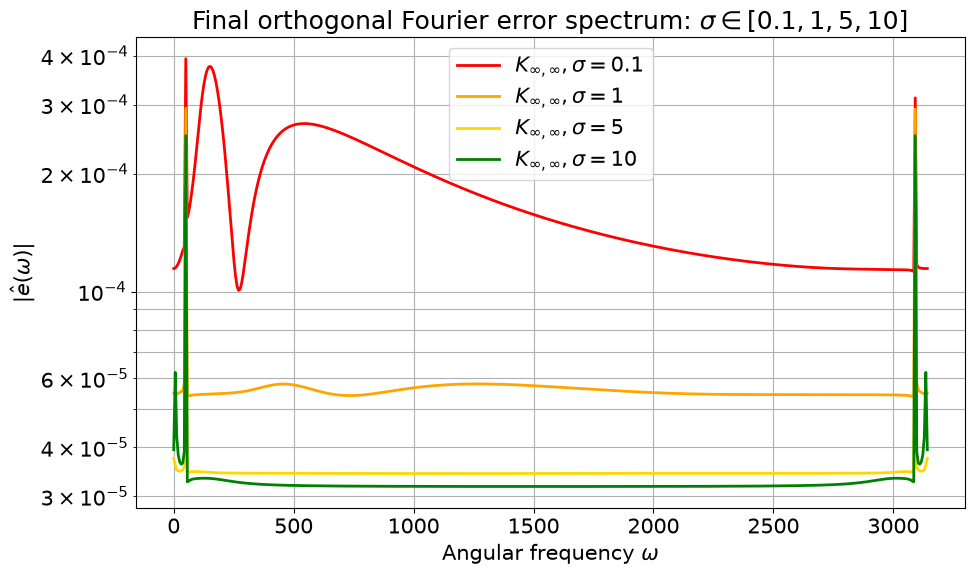

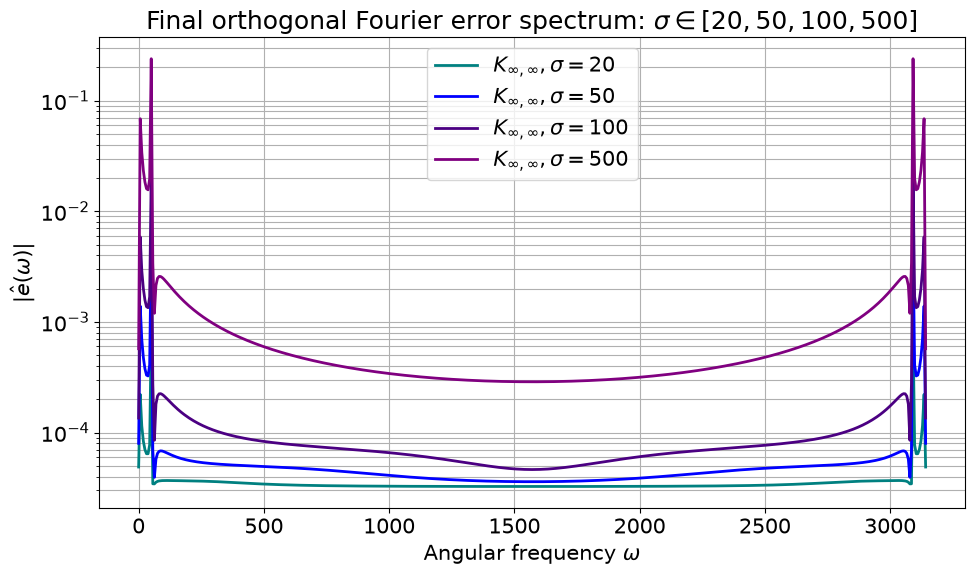

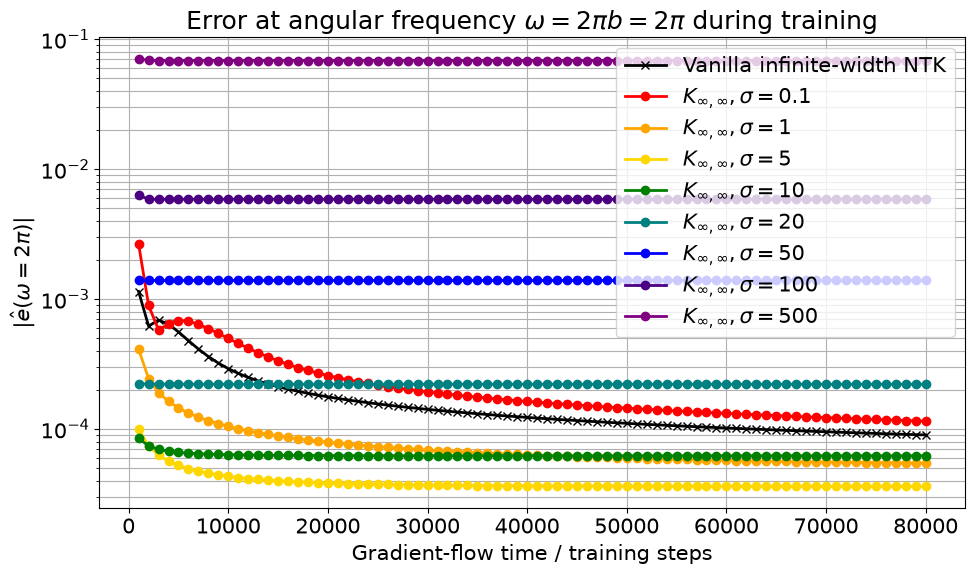

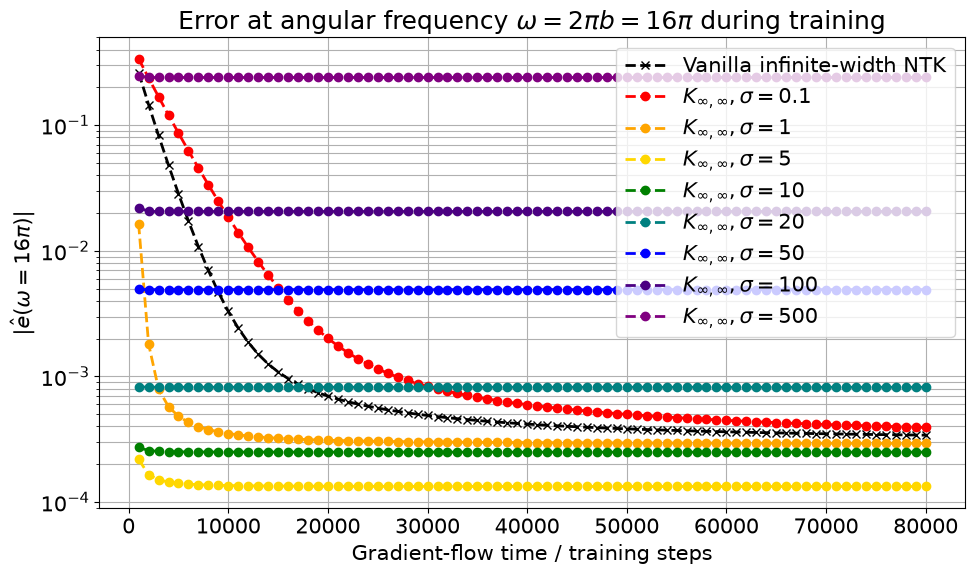

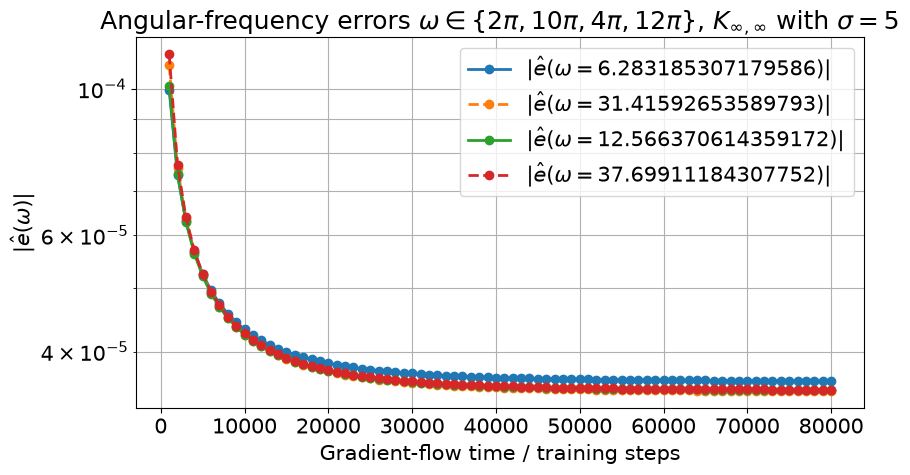

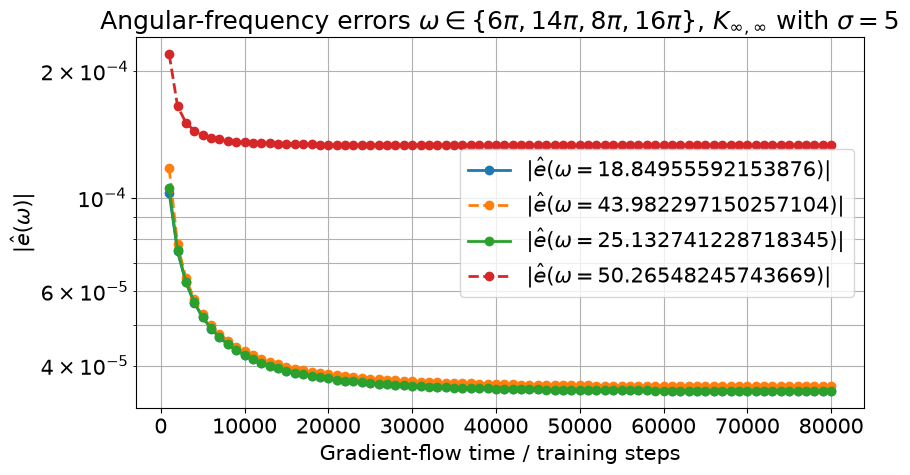


MSE recovered from final regular rFFT spectra
---------------------------------------------
Vanilla infinite-width NTK: 1.4820035579e-05
K_infinity,infinity, sigma=0.1: 3.1830714276e-05
K_infinity,infinity, sigma=1: 3.4401493522e-06
K_infinity,infinity, sigma=5: 1.2491523731e-06
K_infinity,infinity, sigma=10: 1.2973998252e-06
K_infinity,infinity, sigma=20: 4.1578243297e-06
K_infinity,infinity, sigma=50: 1.1137218711e-04
K_infinity,infinity, sigma=100: 1.9246059630e-03
K_infinity,infinity, sigma=500: 2.6096642881e-01


In [74]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Settings
# ============================================================

depth = 2

sigma_w_sq = 2.0
sigma_b_sq = 1.0

learning_rate = 1e-3

sigma_values = [
    0.1,
    1,
    5,
    10,
    20,
    50,
    100,
    500,
]


# These are now angular frequencies omega, not FFT-bin indices.
sigma5_plot1_omegas = [
    2*np.pi,
    10*np.pi,
    4*np.pi,
    12*np.pi,
]

sigma5_plot2_omegas = [
    6*np.pi,
    14*np.pi,
    8*np.pi,
    16*np.pi,
]

low_omegas = [
    2*np.pi,
    4*np.pi,
    6*np.pi,
    8*np.pi,
]

high_omegas = [
    10*np.pi,
    12*np.pi,
    14*np.pi,
    16*np.pi,
]

all_selected_omegas = (
    sigma5_plot1_omegas
    + sigma5_plot2_omegas
)


# ============================================================
# Data
#
# No finite sampled B is used anymore, so the very large
# n_total=6400 required to resolve extreme sampled b_j values
# is no longer necessary.
# ============================================================

nt = 1000

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=nt,
    train_every=2,
)


print("Shapes")
print("------")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)
print("X_all:  ", X_all.shape)
print()


x_plot = np.asarray(
    X_all
).reshape(-1)

y_true_plot = np.asarray(
    y_all
).reshape(-1)


N = x_plot.shape[0]


# ============================================================
# Training/checkpoint steps
# ============================================================

steps_list = [
    1000 * step_idx
    for step_idx in range(
        1,
        81,
    )
]


# ============================================================
# Orthogonal angular frequencies used for error tracking
# ============================================================

omega_orthog1 = nearest_integer_b_omegas(
    [1, 50],
    False,
)

omega_orthog_2 = nearest_integer_b_omegas(
    all_selected_omegas,
    False,
)


# ============================================================
# Helper: prepare zero-initialized infinite-NTK dynamics
#
# y_hat(t)
#   = K_* K^{-1}
#       (I - exp(-eta K t)) y
#
# The eigendecomposition lets us evaluate all checkpoints
# without repeatedly solving a linear system.
# ============================================================

def prepare_kernel_dynamics(
    K_train,
    K_all_train,
    y_train,
    eig_tol_factor=1e-12,
):

    K_train = np.asarray(
        K_train,
        dtype=np.float64,
    )

    K_all_train = np.asarray(
        K_all_train,
        dtype=np.float64,
    )

    y_train_np = np.asarray(
        y_train,
        dtype=np.float64,
    ).reshape(-1)


    # Remove tiny numerical asymmetry.
    K_train = (
        0.5
        * (
            K_train
            + K_train.T
        )
    )


    eigenvalues, Q = np.linalg.eigh(
        K_train
    )


    max_eigenvalue = np.max(
        np.abs(
            eigenvalues
        )
    )


    eig_tol = (
        eig_tol_factor
        * max_eigenvalue
    )


    # Numerical negative/near-zero eigenvalues are treated
    # as zero modes of the PSD kernel.
    eigenvalues = np.where(
        eigenvalues > eig_tol,
        eigenvalues,
        0.0,
    )


    # Q^T y
    target_coefficients = (
        Q.T
        @ y_train_np
    )


    # K_* Q
    cross_kernel_eigenvectors = (
        K_all_train
        @ Q
    )


    return (
        eigenvalues,
        target_coefficients,
        cross_kernel_eigenvectors,
    )


# ============================================================
# Helper: prediction at training step t
# ============================================================

def kernel_prediction_at_step(
    eigenvalues,
    target_coefficients,
    cross_kernel_eigenvectors,
    step,
    learning_rate,
):

    factors = np.zeros_like(
        eigenvalues,
        dtype=np.float64,
    )


    positive = (
        eigenvalues > 0.0
    )


    # Numerically stable evaluation of
    #
    # (1 - exp(-eta lambda t)) / lambda
    factors[
        positive
    ] = (
        -np.expm1(
            -learning_rate
            * eigenvalues[positive]
            * step
        )
        / eigenvalues[positive]
    )


    coefficients_t = (
        factors
        * target_coefficients
    )


    prediction = (
        cross_kernel_eigenvectors
        @ coefficients_t
    )


    return prediction


# ============================================================
# Storage
# ============================================================

results = {}


# ============================================================
# Vanilla/no-map infinite-width NTK
# ============================================================

print(
    "Preparing vanilla infinite-width NTK"
)


K_train_n, _ = analytic_ntk_matrix_2(
    X_train,
    depth=depth,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
)


K_all_train_n, _ = analytic_ntk_matrix_2(
    X_all,
    X_train,
    depth=depth,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
)


(
    eigenvalues_n,
    target_coefficients_n,
    cross_kernel_eigenvectors_n,
) = prepare_kernel_dynamics(
    K_train_n,
    K_all_train_n,
    y_train,
)


ehat_omega1_n_list = []
ehat_omega50_n_list = []

final_error_spectrum_n = None


for n_steps in steps_list:

    y_pred_all_n = kernel_prediction_at_step(
        eigenvalues_n,
        target_coefficients_n,
        cross_kernel_eigenvectors_n,
        n_steps,
        learning_rate,
    )


    vanilla_omega_values = (
        error_at_angular_frequencies(
            y_pred_all_n,
            y_true_plot,
            x_plot,
            omega_orthog1,
        )
    )


    ehat_omega1_n_list.append(
        float(
            vanilla_omega_values[0]
        )
    )


    ehat_omega50_n_list.append(
        float(
            vanilla_omega_values[1]
        )
    )


    # Final checkpoint retained for Parseval.
    if n_steps == steps_list[-1]:

        final_error_spectrum_n = (
            error_fft_magnitude(
                y_pred_all_n,
                y_true_plot,
            )
        )


results["vanilla"] = {
    "steps":
        steps_list,

    "ehat_omega1":
        ehat_omega1_n_list,

    "ehat_omega50":
        ehat_omega50_n_list,

    "final_error_spectrum":
        final_error_spectrum_n,
}


# ============================================================
# K_{infinity,infinity} dynamics for each sigma
# ============================================================

for sigma_idx, sigma in enumerate(
    sigma_values
):

    print()
    print(
        f"sigma={sigma}"
    )


    # --------------------------------------------------------
    # Infinite-Fourier / infinite-width training kernel
    # --------------------------------------------------------

    K_train_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )


    # --------------------------------------------------------
    # Infinite-Fourier / infinite-width cross kernel
    # --------------------------------------------------------

    K_all_train_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_all,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )


    (
        eigenvalues_ff,
        target_coefficients_ff,
        cross_kernel_eigenvectors_ff,
    ) = prepare_kernel_dynamics(
        K_train_ff,
        K_all_train_ff,
        y_train,
    )


    # --------------------------------------------------------
    # Error histories
    # --------------------------------------------------------

    ehat_omega1_ff_list = []
    ehat_omega50_ff_list = []


    selected_omega_history = {
        omega: []
        for omega
        in all_selected_omegas
    }


    final_error_spectrum_ff = None


    for n_steps in steps_list:

        # ----------------------------------------------------
        # Infinite NTK prediction at this training time
        # ----------------------------------------------------

        y_pred_all_ff = kernel_prediction_at_step(
            eigenvalues_ff,
            target_coefficients_ff,
            cross_kernel_eigenvectors_ff,
            n_steps,
            learning_rate,
        )


        # ----------------------------------------------------
        # Error at low/high selected angular frequencies
        # ----------------------------------------------------

        omega1_omega50_values = (
            error_at_angular_frequencies(
                y_pred_all_ff,
                y_true_plot,
                x_plot,
                omega_orthog1,
            )
        )


        ehat_omega1_ff_list.append(
            float(
                omega1_omega50_values[0]
            )
        )


        ehat_omega50_ff_list.append(
            float(
                omega1_omega50_values[1]
            )
        )


        # ----------------------------------------------------
        # Additional angular frequencies for sigma=5
        # ----------------------------------------------------

        if sigma == 5:

            selected_values = (
                error_at_angular_frequencies(
                    y_pred_all_ff,
                    y_true_plot,
                    x_plot,
                    omega_orthog_2,
                )
            )


            for omega, value in zip(
                all_selected_omegas,
                selected_values,
            ):

                selected_omega_history[
                    omega
                ].append(
                    float(
                        value
                    )
                )


        # ----------------------------------------------------
        # Regular rFFT retained for final Parseval/spectrum
        # ----------------------------------------------------

        if n_steps == steps_list[-1]:

            final_error_spectrum_ff = (
                error_fft_magnitude(
                    y_pred_all_ff,
                    y_true_plot,
                )
            )


    # --------------------------------------------------------
    # Store K_{infinity,infinity} results
    # --------------------------------------------------------

    results[sigma] = {

        "steps":
            steps_list,

        "ehat_omega1":
            ehat_omega1_ff_list,

        "ehat_omega50":
            ehat_omega50_ff_list,

        "final_error_spectrum":
            final_error_spectrum_ff,
    }


    if sigma == 5:

        results[sigma][
            "selected_omega_history"
        ] = (
            selected_omega_history
        )


# ============================================================
# Plot settings
# ============================================================

colors = {
    "vanilla": "black",
    0.1: "red",
    1: "orange",
    5: "gold",
    10: "green",
    20: "teal",
    50: "blue",
    100: "indigo",
    500: "purple",
}


split_idx = (
    len(
        sigma_values
    )
    // 2
)


sigma_values_first = (
    sigma_values[
        :split_idx
    ]
)


sigma_values_second = (
    sigma_values[
        split_idx:
    ]
)


# ============================================================
# Angular frequencies for the regular orthogonal rFFT
# ============================================================

dx = (
    x_plot[1]
    - x_plot[0]
)


omega_rfft = (
    2.0
    * np.pi
    * np.fft.rfftfreq(
        N,
        d=dx,
    )
)


# ============================================================
# Plot 1: final orthogonal rFFT spectrum, first sigma group
#
# This replaces the old sampled-b_j plot because there are no
# sampled frequencies in K_{infinity,infinity}.
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for sigma in sigma_values_first:

    plt.semilogy(
        omega_rfft,
        np.asarray(
            results[sigma][
                "final_error_spectrum"
            ]
        ),
        color=colors[sigma],
        linewidth=2,
        label=(
            rf"$K_{{\infty,\infty}}, "
            rf"\sigma={sigma}$"
        ),
    )


plt.xlabel(
    r"Angular frequency $\omega$"
)


plt.ylabel(
    r"$|\hat e(\omega)|$"
)


plt.title(
    r"Final orthogonal Fourier error spectrum: "
    rf"$\sigma \in {sigma_values_first}$"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 2: final orthogonal rFFT spectrum, second sigma group
# ============================================================

plt.figure(
    figsize=(10, 6)
)


for sigma in sigma_values_second:

    plt.semilogy(
        omega_rfft,
        np.asarray(
            results[sigma][
                "final_error_spectrum"
            ]
        ),
        color=colors[sigma],
        linewidth=2,
        label=(
            rf"$K_{{\infty,\infty}}, "
            rf"\sigma={sigma}$"
        ),
    )


plt.xlabel(
    r"Angular frequency $\omega$"
)


plt.ylabel(
    r"$|\hat e(\omega)|$"
)


plt.title(
    r"Final orthogonal Fourier error spectrum: "
    rf"$\sigma \in {sigma_values_second}$"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 3: error at angular frequency omega=2pi
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.semilogy(
    results["vanilla"]["steps"],
    results["vanilla"]["ehat_omega1"],
    color=colors["vanilla"],
    linestyle="-",
    marker="x",
    linewidth=2,
    label="Vanilla infinite-width NTK",
)


for sigma in sigma_values:

    plt.semilogy(
        results[sigma]["steps"],
        results[sigma]["ehat_omega1"],
        color=colors[sigma],
        linestyle="-",
        marker="o",
        linewidth=2,
        label=(
            rf"$K_{{\infty,\infty}}, "
            rf"\sigma={sigma}$"
        ),
    )


plt.xlabel(
    "Gradient-flow time / training steps"
)


plt.ylabel(
    r"$|\hat e(\omega=2\pi)|$"
)


plt.title(
    r"Error at angular frequency "
    r"$\omega=2\pi b=2\pi$ during training"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 4: error at angular frequency omega=16pi
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.semilogy(
    results["vanilla"]["steps"],
    results["vanilla"]["ehat_omega50"],
    color=colors["vanilla"],
    linestyle="--",
    marker="x",
    linewidth=2,
    label="Vanilla infinite-width NTK",
)


for sigma in sigma_values:

    plt.semilogy(
        results[sigma]["steps"],
        results[sigma]["ehat_omega50"],
        color=colors[sigma],
        linestyle="--",
        marker="o",
        linewidth=2,
        label=(
            rf"$K_{{\infty,\infty}}, "
            rf"\sigma={sigma}$"
        ),
    )


plt.xlabel(
    "Gradient-flow time / training steps"
)


plt.ylabel(
    r"$|\hat e(\omega=16\pi)|$"
)


plt.title(
    r"Error at angular frequency "
    r"$\omega=2\pi b=16\pi$ during training"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 5: sigma=5, fixed angular frequencies
#
# Low omega: solid
# High omega: dashed
# ============================================================

sigma_selected = 5


plt.figure(
    figsize=(9, 5)
)


for omega in sigma5_plot1_omegas:

    if omega in low_omegas:
        line_style = "-"
    else:
        line_style = "--"


    plt.semilogy(
        results[
            sigma_selected
        ][
            "steps"
        ],
        results[
            sigma_selected
        ][
            "selected_omega_history"
        ][
            omega
        ],
        linestyle=line_style,
        marker="o",
        linewidth=2,
        label=(
            rf"$|\hat e("
            rf"\omega={omega})|$"
        ),
    )


plt.xlabel(
    "Gradient-flow time / training steps"
)


plt.ylabel(
    r"$|\hat e(\omega)|$"
)


plt.title(
    r"Angular-frequency errors "
    r"$\omega\in\{2\pi,10\pi,4\pi,12\pi\}$, "
    r"$K_{\infty,\infty}$ with $\sigma=5$"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Plot 6: sigma=5, fixed angular frequencies
# ============================================================

plt.figure(
    figsize=(9, 5)
)


for omega in sigma5_plot2_omegas:

    if omega in low_omegas:
        line_style = "-"
    else:
        line_style = "--"


    plt.semilogy(
        results[
            sigma_selected
        ][
            "steps"
        ],
        results[
            sigma_selected
        ][
            "selected_omega_history"
        ][
            omega
        ],
        linestyle=line_style,
        marker="o",
        linewidth=2,
        label=(
            rf"$|\hat e("
            rf"\omega={omega})|$"
        ),
    )


plt.xlabel(
    "Gradient-flow time / training steps"
)


plt.ylabel(
    r"$|\hat e(\omega)|$"
)


plt.title(
    r"Angular-frequency errors "
    r"$\omega\in\{6\pi,14\pi,8\pi,16\pi\}$, "
    r"$K_{\infty,\infty}$ with $\sigma=5$"
)


plt.legend()

plt.grid(
    True,
    which="both",
)

plt.tight_layout()

plt.show()


# ============================================================
# Parseval MSE from the regular rFFT
#
# This remains based on the evenly spaced orthogonal FFT bins.
# ============================================================

print(
    "\nMSE recovered from final regular rFFT spectra"
)

print(
    "---------------------------------------------"
)


mag = np.asarray(
    results[
        "vanilla"
    ][
        "final_error_spectrum"
    ]
)


#double to account for negative values (2*sum)
vanilla_mse_from_fft = (
    mag[0] ** 2
    + mag[-1] ** 2
    + 2.0
    * np.sum(
        mag[
            1:-1
        ] ** 2
    )
)


print(
    f"Vanilla infinite-width NTK: "
    f"{float(vanilla_mse_from_fft):.10e}"
)


for sigma in sigma_values:

    mag = np.asarray(
        results[
            sigma
        ][
            "final_error_spectrum"
        ]
    )


    #double to account for negative values (2*sum)
    mse_from_fft = (
        mag[0] ** 2
        + mag[-1] ** 2
        + 2.0
        * np.sum(
            mag[
                1:-1
            ] ** 2
        )
    )


    print(
        rf"K_infinity,infinity, sigma={sigma}: "
        f"{float(mse_from_fft):.10e}"
    )

Experiment device: cpu:0

sigma=0.1
sigma=0.1: A_0.1(sigma)=3.990e-04, train=1.580e-03, test=1.887e-03, condition=5.024e+06, rank=1.250

sigma=1
sigma=1: A_0.1(sigma)=4.078e-04, train=1.029e-05, test=7.664e-05, condition=3.782e+05, rank=3.288

sigma=5
sigma=5: A_0.1(sigma)=2.555e-04, train=3.117e-08, test=2.028e-05, condition=6.686e+04, rank=7.213

sigma=10
sigma=10: A_0.1(sigma)=5.099e-04, train=3.813e-10, test=2.264e-05, condition=3.273e+04, rank=9.688

sigma=20
sigma=20: A_0.1(sigma)=1.019e-03, train=8.727e-14, test=1.116e-04, condition=1.602e+04, rank=12.690

sigma=50
sigma=50: A_0.1(sigma)=1.307e-03, train=6.077e-30, test=3.927e-03, condition=5.740e+03, rank=17.254

sigma=100
sigma=100: A_0.1(sigma)=1.365e-03, train=4.244e-30, test=9.598e-02, condition=1.812e+03, rank=20.205

sigma=500
sigma=500: A_0.1(sigma)=1.371e-03, train=5.284e-30, test=5.306e-01, condition=8.038e+02, rank=21.013


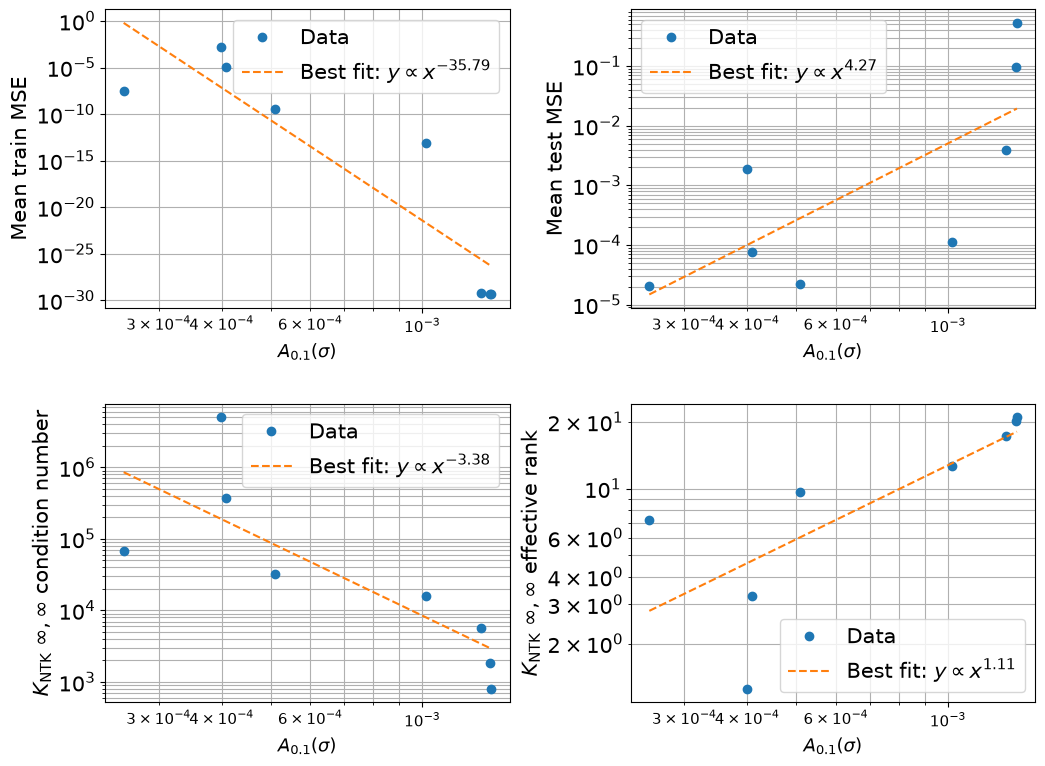

In [83]:
# ----- Condition number, MSE, A metric and effective-rank plots -----
# Analytic K_NTK,infinity,infinity limit

depth = 2
n_steps = 20000
learning_rate = 1e-3

sigma_w_sq = 2.0
sigma_b_sq = 1.0


# ----- Run this experiment on CPU -----

cpu_device = jax.devices("cpu")[0]

X_train, y_train, X_test, y_test, X_all, y_all = make_data(
    n_total=500,
    train_every=2,
)

X_train = jax.device_put(X_train, cpu_device)
y_train = jax.device_put(y_train, cpu_device)

X_test = jax.device_put(X_test, cpu_device)
y_test = jax.device_put(y_test, cpu_device)

X_all = jax.device_put(X_all, cpu_device)
y_all = jax.device_put(y_all, cpu_device)

print("Experiment device:", X_train.device)


sigma_values = [0.1, 1, 5, 10, 20, 50, 100, 500]

MSE_TRAIN_S = []
MSE_TEST_S = []
A_METRIC_S = []
COND_NTK_S = []
EFF_RANK_S = []


# =========================================================
# Vanilla/no-map infinite-width NTK
# =========================================================

K_comp_v, _ = analytic_ntk_matrix_2(
    X_all,
    depth=depth,
    sigma_w_sq=sigma_w_sq,
    sigma_b_sq=sigma_b_sq,
)

cond_v, _ = condition_number_psd(
    K_comp_v,
    rtol=1e-9,
)

eigenvalues_v, eigenvectors_v = ntk_eigendecomposition(
    K_comp_v
)

effective_rank_v = effective_rank_from_eigvals(
    eigenvalues_v
)


# =========================================================
# Analytic K_NTK,infinity,infinity for each sigma
# =========================================================

for sigma in sigma_values:

    print(f"\nsigma={sigma}")


    # -----------------------------------------------------
    # Analytic infinite-Fourier / infinite-width kernels
    # -----------------------------------------------------

    K_train_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    K_test_train_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_test,
        X_train,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )

    K_comp_ff, _ = expected_ntk_and_sigma_derivative(
        sigma,
        X_all,
        depth=depth,
        sigma_w_sq=sigma_w_sq,
        sigma_b_sq=sigma_b_sq,
    )


    # -----------------------------------------------------
    # Analytic finite-time NTK dynamics
    # -----------------------------------------------------

    K_train_np = np.asarray(
        K_train_ff,
        dtype=np.float64,
    )

    K_test_train_np = np.asarray(
        K_test_train_ff,
        dtype=np.float64,
    )

    y_train_np = np.asarray(
        y_train,
        dtype=np.float64,
    ).reshape(-1)

    y_test_np = np.asarray(
        y_test,
        dtype=np.float64,
    ).reshape(-1)


    # Remove tiny numerical asymmetry.
    K_train_np = 0.5 * (
        K_train_np
        + K_train_np.T
    )


    train_eigenvalues, train_eigenvectors = np.linalg.eigh(
        K_train_np
    )


    max_train_eigenvalue = np.max(
        np.abs(train_eigenvalues)
    )

    train_eig_tol = (
        1e-12
        * max_train_eigenvalue
    )


    train_eigenvalues = np.where(
        train_eigenvalues > train_eig_tol,
        train_eigenvalues,
        0.0,
    )


    y_coeff = (
        train_eigenvectors.T
        @ y_train_np
    )


    exponential_factor = (
        1.0
        - np.exp(
            -learning_rate
            * train_eigenvalues
            * n_steps
        )
    )


    # -----------------------------------------------------
    # Training prediction
    # -----------------------------------------------------

    y_pred_train_ff = (
        train_eigenvectors
        @ (
            exponential_factor
            * y_coeff
        )
    )


    train_mse_ff = np.mean(
        (
            y_pred_train_ff
            - y_train_np
        ) ** 2
    )


    # -----------------------------------------------------
    # Test prediction
    # -----------------------------------------------------

    dynamics_factor = np.zeros_like(
        train_eigenvalues,
        dtype=np.float64,
    )


    positive = (
        train_eigenvalues
        > train_eig_tol
    )


    dynamics_factor[positive] = (
        -np.expm1(
            -learning_rate
            * train_eigenvalues[positive]
            * n_steps
        )
        / train_eigenvalues[positive]
    )


    y_pred_test_ff = (
        K_test_train_np
        @ train_eigenvectors
        @ (
            dynamics_factor
            * y_coeff
        )
    )


    test_mse_ff = np.mean(
        (
            y_pred_test_ff
            - y_test_np
        ) ** 2
    )


    # -----------------------------------------------------
    # Condition number
    # -----------------------------------------------------

    cond_ff, _ = condition_number_psd(
        K_comp_ff,
        rtol=1e-9,
    )


    # -----------------------------------------------------
    # Eigendecomposition on full grid
    # -----------------------------------------------------

    eigenvalues, eigenvectors = ntk_eigendecomposition(
        K_comp_ff
    )


    eigenvalues = np.asarray(
        eigenvalues
    ).reshape(-1)

    eigenvectors = np.asarray(
        eigenvectors
    )


    # -----------------------------------------------------
    # A_{0.1}(sigma)
    # -----------------------------------------------------

    c_ordered = (
        eigenvectors.T
        @ np.asarray(y_all).reshape(-1)
    )


    n_remove = int(
        np.ceil(
            0.10
            * len(eigenvalues)
        )
    )


    keep = np.zeros(
        len(eigenvalues),
        dtype=bool,
    )

    keep[n_remove:] = True


    A = (
        np.sum(
            c_ordered[keep] ** 2
        )
        / np.sum(
            c_ordered ** 2
        )
    )


    # -----------------------------------------------------
    # Effective rank
    # -----------------------------------------------------

    effective_rank = effective_rank_from_eigvals(
        eigenvalues
    )


    # -----------------------------------------------------
    # Store results
    # -----------------------------------------------------

    MSE_TRAIN_S.append(
        float(train_mse_ff)
    )

    MSE_TEST_S.append(
        float(test_mse_ff)
    )

    A_METRIC_S.append(
        float(A)
    )

    COND_NTK_S.append(
        float(cond_ff)
    )

    EFF_RANK_S.append(
        float(effective_rank)
    )


    print(
        f"sigma={sigma}: "
        f"A_0.1(sigma)={A_METRIC_S[-1]:.3e}, "
        f"train={MSE_TRAIN_S[-1]:.3e}, "
        f"test={MSE_TEST_S[-1]:.3e}, "
        f"condition={COND_NTK_S[-1]:.3e}, "
        f"rank={EFF_RANK_S[-1]:.3f}"
    )


# =========================================================
# Log-log plots with least-squares best-fit lines
# =========================================================

def plot_loglog_fit(
    ax,
    x,
    y,
    ylabel,
):

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )


    valid = (
        np.isfinite(x)
        & np.isfinite(y)
        & (x > 0)
        & (y > 0)
    )


    x = x[valid]
    y = y[valid]


    # Least-squares fit:
    # log10(y) = slope * log10(x) + intercept
    slope, intercept = np.polyfit(
        np.log10(x),
        np.log10(y),
        1,
    )


    # Evaluate only at the existing x values.
    order = np.argsort(x)
    x_sorted = x[order]


    y_fit = 10 ** np.polyval(
        [slope, intercept],
        np.log10(x_sorted),
    )


    ax.loglog(
        x,
        y,
        "o",
        label="Data",
    )


    ax.loglog(
        x_sorted,
        y_fit,
        "--",
        label=rf"Best fit: $y \propto x^{{{slope:.2f}}}$",
    )


    ax.set_xlabel(
        r"$A_{0.1}(\sigma)$",
        fontsize=13,
        labelpad=5,
    )

    ax.set_ylabel(
        ylabel
    )

    # Slightly larger x-axis tick labels
    ax.tick_params(
        axis="x",
        which="both",
        labelsize=11,
    )

    ax.grid(
        True,
        which="both",
    )

    ax.legend()


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
)


plot_loglog_fit(
    axes[0, 0],
    A_METRIC_S,
    MSE_TRAIN_S,
    "Mean train MSE",
)


plot_loglog_fit(
    axes[0, 1],
    A_METRIC_S,
    MSE_TEST_S,
    "Mean test MSE",
)


plot_loglog_fit(
    axes[1, 0],
    A_METRIC_S,
    COND_NTK_S,
    r"$K_{\mathrm{NTK}}\ \infty,\infty$ condition number",
)


plot_loglog_fit(
    axes[1, 1],
    A_METRIC_S,
    EFF_RANK_S,
    r"$K_{\mathrm{NTK}}\ \infty,\infty$ effective rank",
)


fig.subplots_adjust(
    hspace=0.32,
    wspace=0.30,
)

plt.show()